"""
- Objective:
    - Analyze the GENIE3 inferred adjacency matrix
- Method:
    - Load the ground truth adjacency matrix
    - Load the inferred graphs
    - Compute the AUPR and AUPRC, EP, EP@K1 and EP@K2
    - Analyze correlation between AUPR, AUPRC with the motif abundance
"""

/opt/micromamba/envs/venv_trajinf/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.21) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/opt/micromamba/envs/venv_trajinf/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.21) which Google will stop supporting in new releases of google.cloud._storage_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud._storage_v2 past that date.
  warnings.warn(message, FutureWarning)
/opt/micromamba/envs/venv_trajinf/lib/python3.10/site-packages/goo

Loading /home/jupyter/../AETL_SUR/GRNgen/configs/config_Bi-Mutual.json
Loading gs://aetl_sur-axe-workspace-prod-db34/data/generation/grngen/human_trrust/human_trrust_results.parquet


Processing graphs: 100%|██████████| 100/100 [08:33<00:00,  5.14s/it]


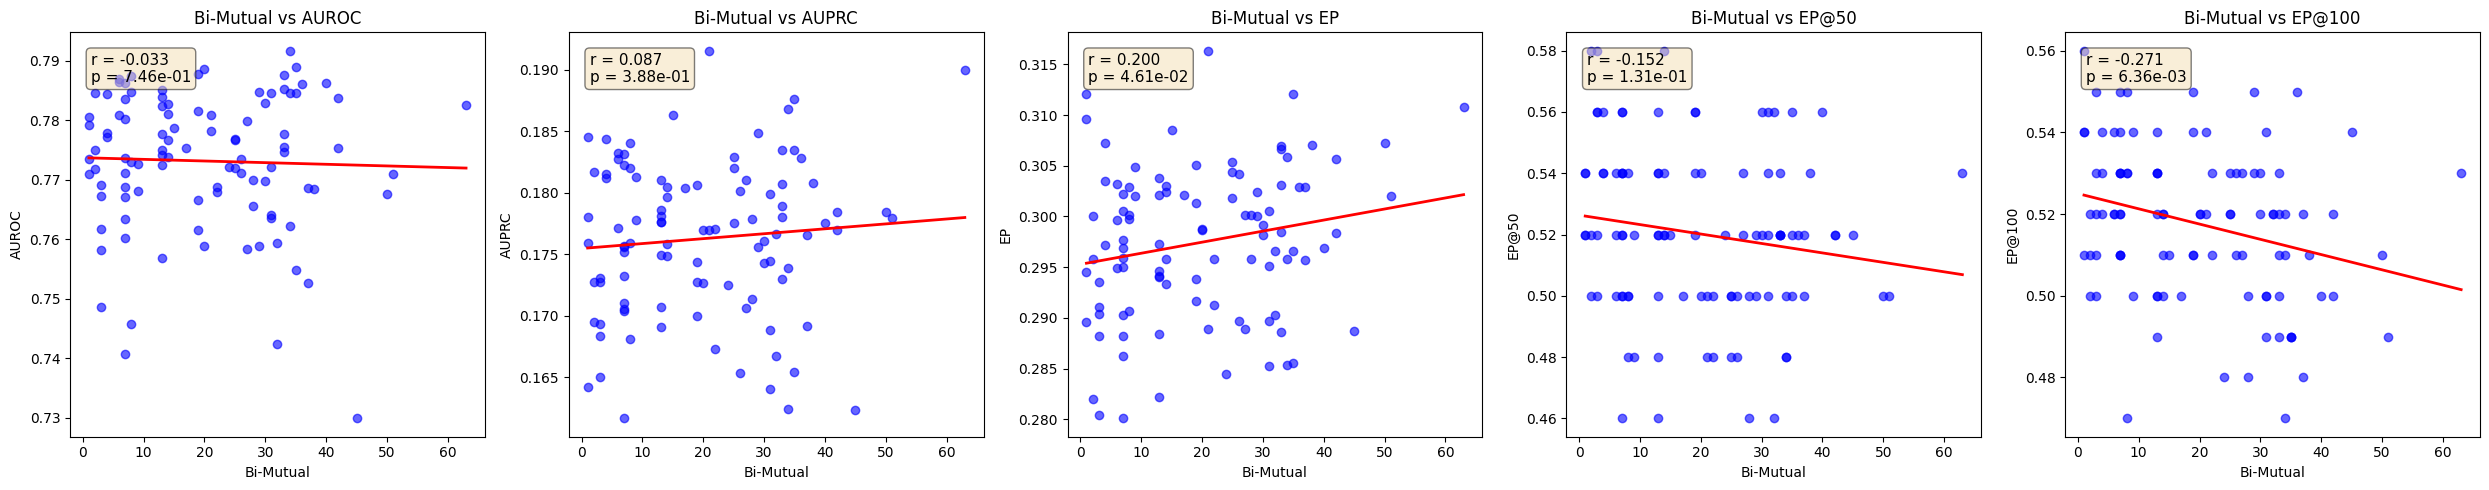

Loading /home/jupyter/../AETL_SUR/GRNgen/configs/config_Cascade.json
Loading gs://aetl_sur-axe-workspace-prod-db34/data/generation/grngen/human_trrust/human_trrust_results.parquet


Processing graphs: 100%|██████████| 100/100 [08:22<00:00,  5.03s/it]


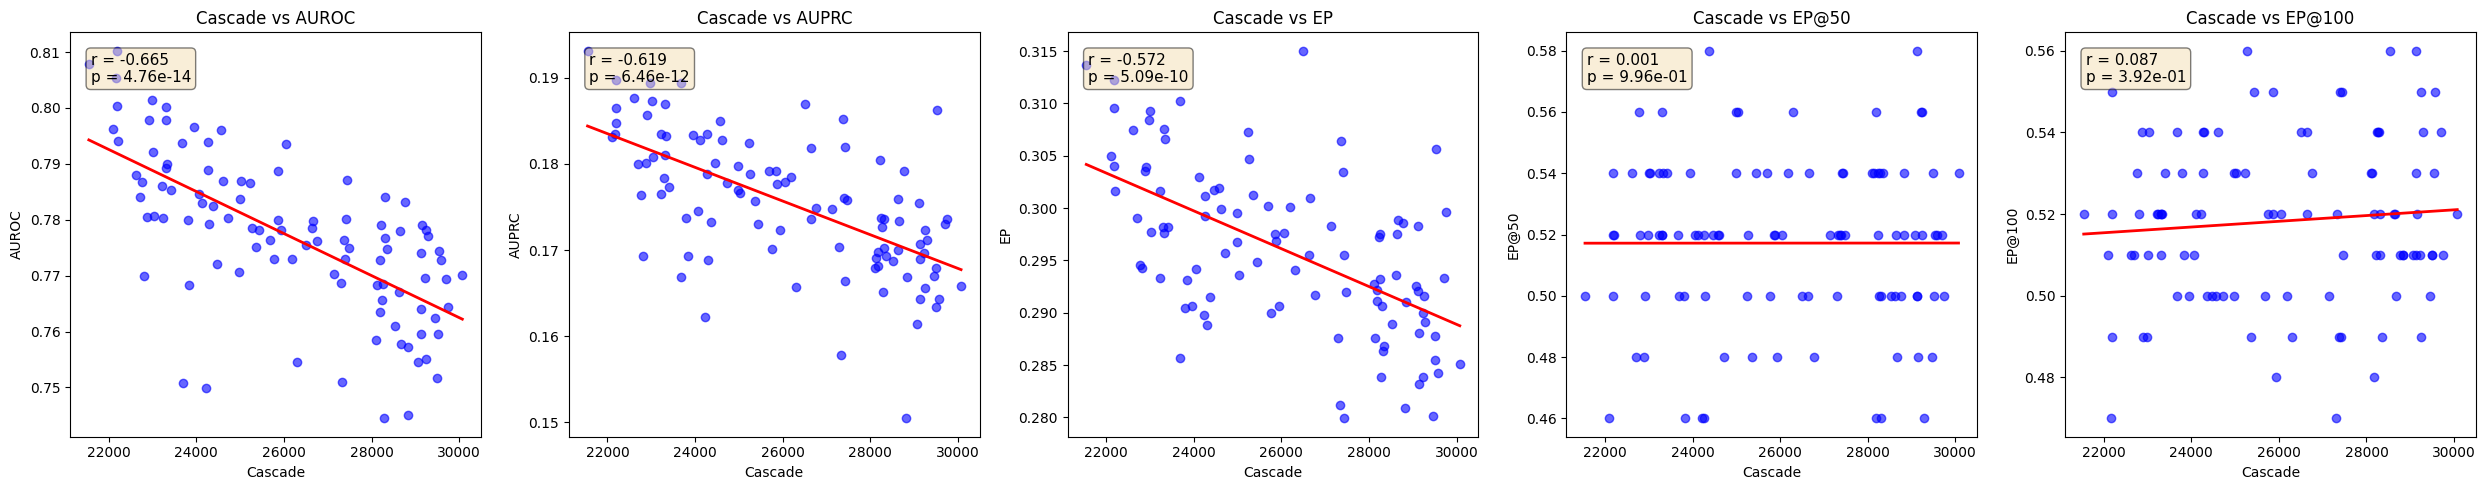

Loading /home/jupyter/../AETL_SUR/GRNgen/configs/config_Clique.json
Loading gs://aetl_sur-axe-workspace-prod-db34/data/generation/grngen/human_trrust/human_trrust_results.parquet


Processing graphs: 100%|██████████| 100/100 [08:22<00:00,  5.03s/it]


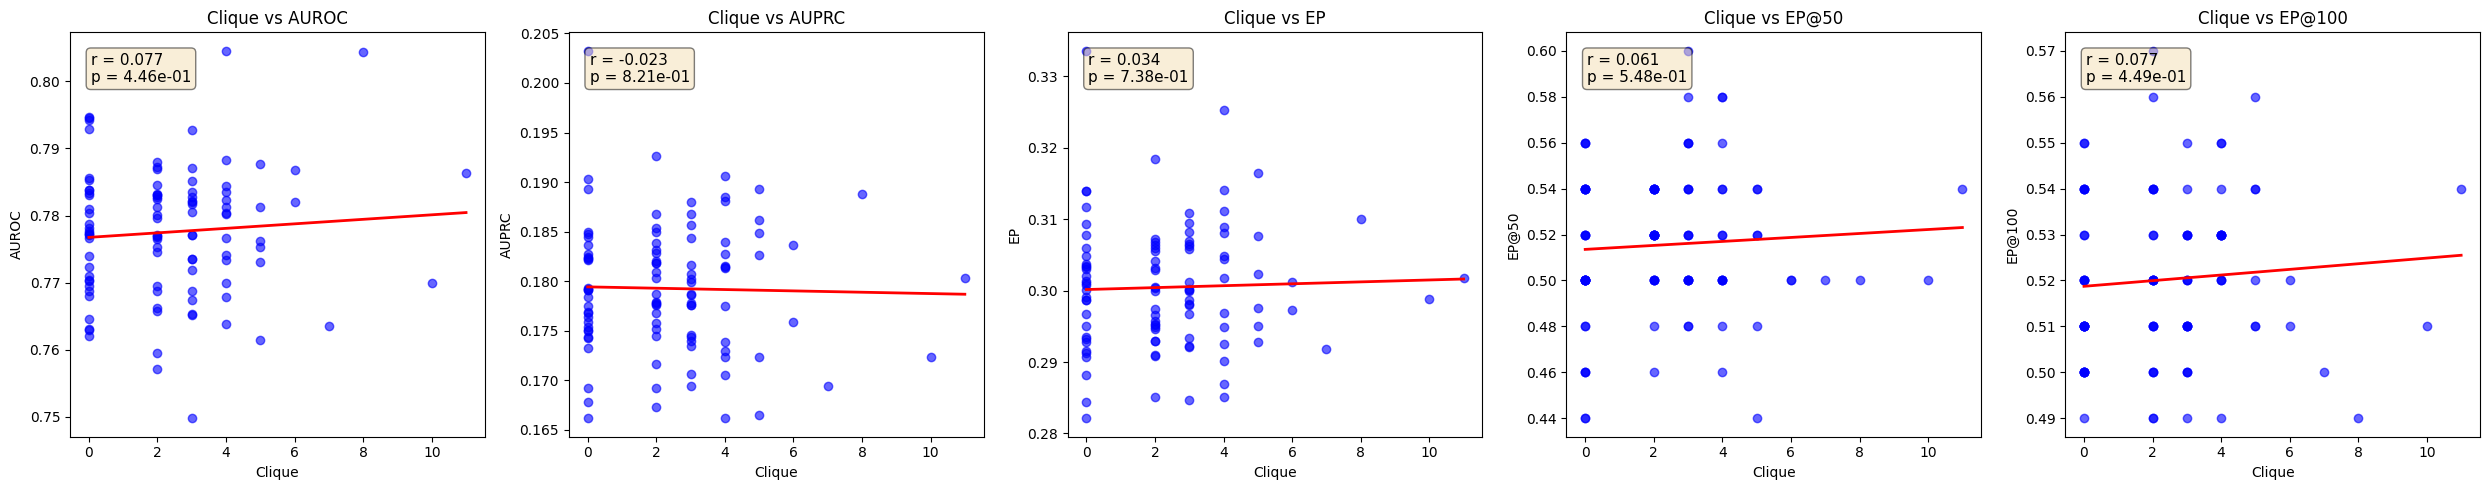

Loading /home/jupyter/../AETL_SUR/GRNgen/configs/config_FBL.json
Loading gs://aetl_sur-axe-workspace-prod-db34/data/generation/grngen/human_trrust/human_trrust_results.parquet


Processing graphs:   6%|▌         | 6/100 [00:30<08:05,  5.16s/it]

In [ ]:
import sys
import os
import json

import networkx as nx
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from grngen import *

from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from scipy import sparse
import re
import gcsfs

K1 = 50
K2 = 100

feature_list = [
    'Bi-Mutual', 'Cascade', 'Clique', 'FBL', 
    'FFL', 
    'Fan-In', 
    'Fan-Out', 'Mutual-Cascade', 
    'Mutual-In', 'Mutual-Out', 'Regulated-Mutual', 
    'Regulating-Mutual', 'Semi-Clique',
]

# New paths
config_folder = os.path.expanduser("~/../AETL_SUR/GRNgen/configs")
INFERENCE_BUCKET = "gs://aetl_sur-axe-workspace-prod-db34/data/inference"

# Initialize GCS filesystem
fs = gcsfs.GCSFileSystem()

for target_feature in feature_list:
    config_file = f"{config_folder}/config_{target_feature}.json"
    print(f"Loading {config_file}")
    with open(config_file) as f:
        config = json.load(f)

    print(f"Loading {config['parquet_folder']}")
    graphs = load_graphs_from_parquet(config['parquet_folder'], config['graph_id_list'])
    
    df_sensi = pd.read_parquet(
        config['parquet_folder'],
        columns=['graph_id', config['target_feature']],
        filters=[('graph_id', 'in', config['graph_id_list'])]
    )

    results = []

    for graph_id in tqdm(graphs.keys(), desc="Processing graphs"):
        inf_adj_mx_file = f"{INFERENCE_BUCKET}/{config['target_feature']}/inf_adj_mx_vim_graphid{graph_id}.npz"
        
        # Load from GCS using gcsfs
        with fs.open(inf_adj_mx_file, 'rb') as f:
            inf_adj_mx = np.load(f, allow_pickle=True)
            #Indented to ensure file is read and used before closed
            auroc, auprc, ep, ep_k1, ep_k2 = evaluate_inference_epr(
                nx.adjacency_matrix(graphs[graph_id]), 
                inf_adj_mx['inferred_adj_mx'],
                k1=K1,
                k2=K2
            )

        results.append({
            'graph_id': graph_id, 
            'AUROC': auroc, 
            'AUPRC': auprc, 
            'EP': ep,
            f'EP@{K1}': ep_k1,
            f'EP@{K2}': ep_k2
        })

    results_df = pd.DataFrame(results).set_index('graph_id')
    df_sensi = df_sensi.set_index('graph_id')
    df_sensi = df_sensi.join(results_df, how='left')
    
    # Save outputs to GCS
    output_folder = f"{INFERENCE_BUCKET}/{config['target_feature']}"
    
    # Save CSV to GCS
    with fs.open(f"{output_folder}/{config['target_feature']}_inference_metrics.csv", 'w') as f:
        df_sensi.to_csv(f)
    
    # Plot
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    scatter_with_correlation(df_sensi, config['target_feature'], 'AUROC', ax=axes[0])
    scatter_with_correlation(df_sensi, config['target_feature'], 'AUPRC', ax=axes[1])
    scatter_with_correlation(df_sensi, config['target_feature'], 'EP', ax=axes[2])
    scatter_with_correlation(df_sensi, config['target_feature'], f'EP@{K1}', ax=axes[3])
    scatter_with_correlation(df_sensi, config['target_feature'], f'EP@{K2}', ax=axes[4])
    plt.tight_layout()
    
    # Save plot to GCS
    with fs.open(f"{output_folder}/{config['target_feature']}_inference_metric.png", 'wb') as f:
        plt.savefig(f, format='png')
    with fs.open(f"{output_folder}/{config['target_feature']}_inference_metric.pdf", 'wb') as f:
        plt.savefig(f, format='pdf')
    plt.show()